In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  


In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from region import Region
from functions import Functions
fns = Functions()

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pickle
from cartopy.feature import LAND

In [4]:
# load raw data
sla_ = SLA(deg=0.25).da
elevation_ = GEBCO(coarsen_factor=4).ds.elevation
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dotds = DOT().ds.rename({'ug':'u10','vg':'v10'})
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
gyre_index = xr.open_dataarray('gyre_index.nc')

# lwe_ds = GRACE().ds
# sha_ds_sla = StericHeight(ssh_ref='DOT',
#                       ssh=sla_,#SLA(deg=1).da,
#                       msl=None,
#                       lwe=lwe_ds.lwe_thickness
#                       ).get_sha()



In [5]:
# define areas of interest and crop elevation for plotting speed
extent_ac = [138,152,-68,-63]
extent_ea = [60,160,-70,-60]

elevation_ea = elevation_.sel(latitude = slice(extent_ea[2], extent_ea[3]), longitude = slice(extent_ea[0],extent_ea[1]))
elevation_ac = elevation_.sel(latitude = slice(extent_ac[2], extent_ac[3]), longitude = slice(extent_ac[0],extent_ac[1]))

In [6]:
# crop data to required areas
region_ac = Region('AC',extent_ac,elevation=elevation_ac)
region_ac_shelf = Region('ACS',extent_ac,elevation=elevation_ac,min_elevation=-1000)
region_ea = Region('EA',extent_ea)

extent_gyre = [145,149,-66.5,-65.5]
region_gyre = Region('Gyre',extent=extent_gyre)

winds_ea = region_ea.crop_da(winds_)

sla = region_ac.crop_da(sla_)
sla_shelf = region_ac_shelf.crop_da(sla_)
sla_gyre = region_gyre.crop_da(sla_)
winds = region_ac.crop_da(winds_)
# dot =region_ac.crop_da(dotds)
sice = region_ac.crop_da(sice_)
sic_shelf = region_ac_shelf.crop_da(sice_)
# lwe_shelf = region_ac_shelf.crop_da(lwe_ds)
# sha_shelf = region_ac_shelf.crop_da(sha_ds_sla)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

In [7]:
# compute geostrophc currents and detrend

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

dtu = utls.detrend_dim(u,dim='time')
dtv = utls.detrend_dim(v,dim='time')
dt_geos = xr.Dataset({'u10':dtu,'v10':dtv})

# also detrend the wind, SIC nd SLA
dt_winds = xr.Dataset({
    'u10': utls.detrend_dim(winds.u10,'time'),
    'v10': utls.detrend_dim(winds.v10,'time')
})

dt_sic = utls.detrend_dim(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])),'time')
dt_sla = utls.detrend_dim(sla.interpolate_na(dim='time'),'time')


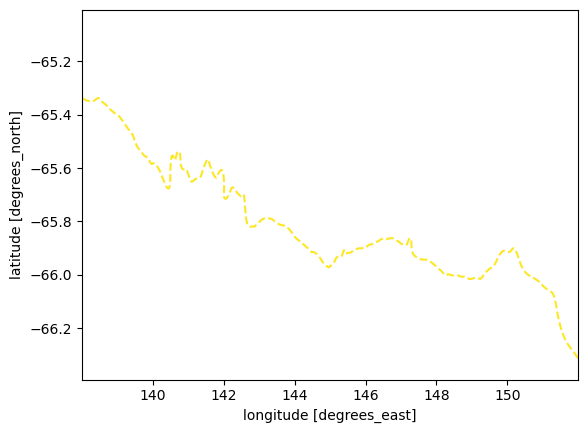

In [8]:
# USE contur plot to isolate coords of -1000 isobath
cc=elevation_ac.sel(latitude=slice(-66.4,-65)).plot.contour(levels=[-1000])

In [9]:
# get coords from contour
lats = xr.DataArray(cc.allsegs[0][0].T[1],coords={'longitude':cc.allsegs[0][0].T[0]})
asclats = lats.sortby('longitude').interp(longitude=geos.longitude,kwargs={'fill_value':'extrapolate'})

# get geostrophic currents along the slope
geos['asc_latitude'] = xr.DataArray(asclats,coords={'longitude':geos.longitude})
geos['asc'] = geos.u10.sel(latitude=geos.asc_latitude,method='nearest')

# turn into radians for vector mathematics
R = 6371000
lat_radians = np.deg2rad(geos.asc_latitude)

# find x and y distnace between each point onthe contour
dx = R * np.cos(lat_radians[:-1]) * np.deg2rad(np.diff(geos.longitude))
dy = R * np.deg2rad(np.diff(geos.asc_latitude))

# FIND linear distance between each point on the contour
delta = np.stack([dx,dy],axis=1)
t_hat = delta / np.linalg.norm(delta, axis=1)[:, None]

# Interpolate u and v onto path points for all times
u_path = geos.u10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)
v_path = geos.v10.interp(latitude=geos.asc_latitude, longitude=geos.longitude)

# Convert points into segments and turn into dataarray
u_seg = u_path[:, :-1]  # drop last point (segments)
v_seg = v_path[:-1, :]
dathatx = xr.DataArray(t_hat[:,0],coords={'longitude':u_seg.longitude})
dathaty = xr.DataArray(t_hat[:,1],coords={'longitude':u_seg.longitude})

# use trig to compute speed along segment
v_along = u_seg * dathatx + v_seg * dathaty 

In [10]:
# strength of easterlies and westerlies
eastl = -winds.u10.sel(latitude=slice(-68,-65)).mean(['latitude','longitude'])
westl = winds.u10.sel(latitude=slice(-64,-55)).mean(['latitude','longitude'])
# strength of ASC/ACC
#asc = geos.u10.sel(latitude=slice(-66.25,-65.5)).mean(['latitude','longitude'])
acc = geos.u10.sel(latitude=slice(-65,-63)).mean(['latitude','longitude'])
# coastal ssh
cssh = sla_shelf.mean(['latitude','longitude'])
csic = sic_shelf.mean(['latitude','longitude'])
gssh = sla_gyre.mean(['latitude','longitude'])
# # sha & grace
# csha = sha_shelf.sha.mean(['latitude','longitude'])
# clwe = lwe_shelf.lwe_thickness.mean(['latitude','longitude'])

In [11]:

asc = -v_along.mean('longitude')

In [ ]:
dt_eastl = utls.detrend_dim(eastl,'time')
dt_westl = utls.detrend_dim(westl,'time')
dt_acc = utls.detrend_dim(acc,'time')
dt_asc = utls.detrend_dim(asc,'time')
dt_cssh = utls.detrend_dim(cssh,'time')
dt_csic = utls.detrend_dim(csic,'time')
dt_eastl = utls.detrend_dim(eastl,'time')
dt_sam = utls.detrend_dim(sam,'time')



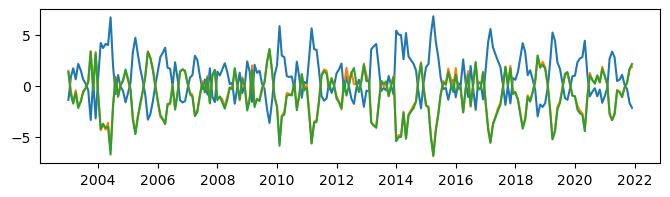

In [13]:
fig,ax = plt.subplots(figsize=(8,2))
ax.plot(geos.time,asc)
ax.plot(geos.time,geos.asc.mean('longitude'))
ax.plot(geos.time,v_along.mean('longitude'))

In [14]:
#repeat with extra plots
sose145 = xr.open_dataset('sose_shelf_145.nc')
glorys = xr.open_dataset('glorys_shelf_145.nc')

In [15]:
sigdiff = xr.open_dataarray('sigdiff.nc')

In [26]:
# make glorys look like sose
glorys = glorys.sel(longitude = 145,method='nearest').sel(latitude=slice(sose145.YC.min(),sose145.YC.max()))#.mean('latitude')

In [35]:
ssal = sose145.SALT.sel(Z=slice(0,-500)).mean(['Z','YC'])
sthe = sose145.THETA.sel(Z=slice(0,-500)).mean(['Z','YC'])

s_top100t = -sose145.THETA.sel(Z=slice(0,-100)).integrate('Z').mean('YC')
s_top100s = -sose145.SALT.sel(Z=slice(0,-100)).integrate('Z').mean('YC')

s_breakt = -sose145.THETA.sel(Z=slice(-200,-400)).integrate('Z').sel(YC = slice(-66.5,-66)).mean('YC')
s_breaks = -sose145.SALT.sel(Z=slice(-200,-400)).integrate('Z').sel(YC = slice(-66.5,-66)).mean('YC')


dt_ssal = utls.detrend_dim(ssal,'time')
dt_sthe = utls.detrend_dim(sthe,'time')

# surface params
dt_ssal100 = utls.detrend_dim(s_top100s,'time')
dt_sthe100 = utls.detrend_dim(s_top100t,'time')

# Shelfd break oarams
dt_sbreaks = utls.detrend_dim(s_breaks,'time')
dt_sbreakt = utls.detrend_dim(s_breakt,'time')


dt_gi = utls.detrend_dim(gyre_index,'time')

In [27]:
glorys

<xarray.Dataset> Size: 8MB
Dimensions:       (time: 228, latitude: 19, depth: 35)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-12-01
  * latitude      (latitude) float32 76B -67.5 -67.42 -67.33 ... -66.08 -66.0
  * depth         (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
    longitude     float32 4B 145.0
    month         (time) int64 2kB ...
Data variables: (12/14)
    siconc        (time, latitude, depth) float32 606kB ...
    mlotst        (time, latitude, depth) float32 606kB ...
    sithick       (time, latitude, depth) float32 606kB ...
    zos           (time, latitude, depth) float32 606kB ...
    thetao        (time, depth, latitude) float32 606kB ...
    so            (time, depth, latitude) float32 606kB ...
    ...            ...
    vo            (time, depth, latitude) float32 606kB ...
    asc_latitude  (time, depth) float64 64kB ...
    asc           (time, depth) float32 32kB ...
    pressure      (time, depth) float64 64kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    rho           (time, depth, latitude) float64 1MB ...
    sigma0        (time, depth, latitude) float64 1MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Monthly mean fields for product GLOBAL_REANALYSIS_PHY_...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MERCATOR GLORYS12V1
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_my_0.083deg_P1M-m_202311
    subset:date:       2025-12-04T07:49:47.532Z

In [34]:
glorys.depth

<xarray.DataArray 'depth' (depth: 35)> Size: 140B
array([4.940250e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00, 5.078224e+00,
       6.440614e+00, 7.929560e+00, 9.572997e+00, 1.140500e+01, 1.346714e+01,
       1.581007e+01, 1.849556e+01, 2.159882e+01, 2.521141e+01, 2.944473e+01,
       3.443415e+01, 4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02, 1.558507e+02,
       1.861256e+02, 2.224752e+02, 2.660403e+02, 3.181274e+02, 3.802130e+02,
       4.539377e+02, 5.410889e+02, 6.435668e+02, 7.633331e+02, 9.023393e+02],
      dtype=float32)
Coordinates:
  * depth      (depth) float32 140B 0.494 1.541 2.646 ... 643.6 763.3 902.3
    longitude  float32 4B 145.0
Attributes:
    standard_name:  depth
    long_name:      Depth
    units:          m
    unit_long:      Meters
    axis:           Z
    positive:       down

In [38]:
gsal = glorys.so.sel(depth=slice(0,500)).mean(['depth','latitude'])
gthe = glorys.thetao.sel(depth=slice(0,500)).mean(['depth','latitude'])

g_top100t = glorys.thetao.sel(depth=slice(0,100)).integrate('depth').mean('latitude')
g_top100s = glorys.so.sel(depth=slice(0,100)).integrate('depth').mean('latitude')

g_breakt = glorys.thetao.sel(depth=slice(200,400)).integrate('depth').sel(latitude = slice(-66.5,-66)).mean('latitude')
g_breaks = glorys.so.sel(depth=slice(200,400)).integrate('depth').sel(latitude = slice(-66.5,-66)).mean('latitude')

dt_gsal = utls.detrend_dim(gsal,'time')
dt_gthe = utls.detrend_dim(gthe,'time')

# surface params
dt_gsal100 = utls.detrend_dim(g_top100s,'time')
dt_gthe100 = utls.detrend_dim(g_top100t,'time')

# Shelfd break oarams
dt_gbreaks = utls.detrend_dim(g_breaks,'time')
dt_gbreakt = utls.detrend_dim(g_breakt,'time')


In [39]:
detrended_vars={
    'Easterlies': dt_eastl,
    'Westerlies': dt_westl,
    'ACC': dt_acc,
    'Shelf SLA': dt_cssh,
    'Shelf SIC': dt_sic,
    'Gyre Index': dt_gi,
    'SAM Index': dt_sam,
    'ASC': dt_asc,
    'Shelf mean temperature (SOSE)': dt_sthe,
    'Shelf mean salinity (SOSE)': dt_ssal,
    'Shelf mean temperature (GLORYS)': dt_gthe,
    'Shelf mean salinity (GLORYS)': dt_gsal,
    'Shelf surface temperature (SOSE)': dt_sthe100,
    'Shelf surface salinity (SOSE)': dt_ssal100,
    'Shelf surface temperature (GLORYS)': dt_gthe100,
    'Shelf surface salinity (GLORYS)': dt_gsal100,
    'Shelf break temperature (SOSE)': dt_sbreakt,
    'Shelf break salinity (SOSE)': dt_sbreaks,
    'Shelf break temperature (GLORYS)': dt_gbreakt,
    'Shelf break salinity (GLORYS)': dt_gbreaks,
    'Shelf break density difference (SOSE)': utls.detrend_dim(sigdiff,'time')
}
import pickle

with open('detrended_vars.pickle', 'wb') as handle:
    pickle.dump(detrended_vars, handle, protocol=pickle.HIGHEST_PROTOCOL)